# 3D Reconstruction Demo

This notebook demonstrates the 3D pose reconstruction process from synchronized multi-view pose sequences.

It also evaluates reconstruction stability using:

- Bone Length Variance
- Temporal Smoothness Error

## 1. Import Libraries

Load required libraries for numerical computation, visualization, and 3D evaluation.

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.evaluation.evaluate_3d import (
    bone_length_variance,
    temporal_smoothness_error
)

print("Project Root:", PROJECT_ROOT)

Project Root: C:\Users\Admin\Desktop\MyProject\P_DADN\Pose-based-time-synchronization


## 2. Load Reconstructed 3D Pose

Load the reconstructed 3D pose sequence generated by the main pipeline.

In [2]:
session = "session_02"

pose3d_path = PROJECT_ROOT / f"data/processed/pose3d/{session}_pose3d.npy"

pose3d = np.load(pose3d_path)

print("3D pose shape:", pose3d.shape)

3D pose shape: (267, 33, 3)


## 3. Compute 3D Reconstruction Metrics

Two metrics are used to evaluate the stability of the reconstructed 3D pose sequence.

In [3]:
bone_var = bone_length_variance(pose3d)
smoothness = temporal_smoothness_error(pose3d)

print("Bone Length Variance:", bone_var)
print("Temporal Smoothness Error:", smoothness)

Bone Length Variance: 1.7586103677749634
Temporal Smoothness Error: 299.152099609375


## 4. Visualize One 3D Pose Frame

This section visualizes one reconstructed 3D pose frame using MediaPipe body landmark connections.

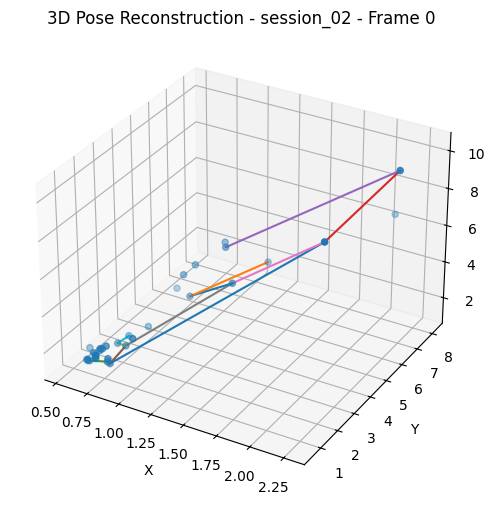

In [4]:
POSE_CONNECTIONS = [
    (11, 12),
    (11, 13),
    (13, 15),
    (12, 14),
    (14, 16),
    (11, 23),
    (12, 24),
    (23, 24),
    (23, 25),
    (25, 27),
    (24, 26),
    (26, 28)
]

frame_idx = 0
pose = pose3d[frame_idx]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

valid = ~np.isnan(pose).any(axis=1)

ax.scatter(
    pose[valid, 0],
    pose[valid, 1],
    pose[valid, 2]
)

for start, end in POSE_CONNECTIONS:
    if valid[start] and valid[end]:
        ax.plot(
            [pose[start, 0], pose[end, 0]],
            [pose[start, 1], pose[end, 1]],
            [pose[start, 2], pose[end, 2]]
        )

ax.set_title(f"3D Pose Reconstruction - {session} - Frame {frame_idx}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

## Observation

The reconstructed 3D pose shows the spatial structure of the human body based on two synchronized 2D pose sequences.

Because the current implementation uses simplified camera matrices, the reconstructed pose is mainly used for stability analysis rather than precise metric-scale 3D reconstruction.

## 5. Load Delta Offset Experiment Results

This section loads the experimental results that analyze how different temporal offsets affect 3D reconstruction quality.

In [5]:
delta_path = PROJECT_ROOT / f"results/tables/{session}_delta_offset.json"

with open(delta_path, "r") as f:
    delta_results = json.load(f)

print("Number of records:", len(delta_results))
delta_results

Number of records: 7


[{'offset': 27,
  'delta': -30,
  'bone_length_variance': 1.9554016590118408,
  'temporal_smoothness_error': 880.417724609375},
 {'offset': 37,
  'delta': -20,
  'bone_length_variance': 1.9764087200164795,
  'temporal_smoothness_error': 46.0971794128418},
 {'offset': 47,
  'delta': -10,
  'bone_length_variance': 1.9553771018981934,
  'temporal_smoothness_error': 169.18035888671875},
 {'offset': 57,
  'delta': 0,
  'bone_length_variance': 1.7586103677749634,
  'temporal_smoothness_error': 299.152099609375},
 {'offset': 67,
  'delta': 10,
  'bone_length_variance': 1.598204255104065,
  'temporal_smoothness_error': 70.75303649902344},
 {'offset': 77,
  'delta': 20,
  'bone_length_variance': 1.6247320175170898,
  'temporal_smoothness_error': 104.0850830078125},
 {'offset': 87,
  'delta': 30,
  'bone_length_variance': 1.6533081531524658,
  'temporal_smoothness_error': 477.6639099121094}]

## 6. Delta Offset vs Bone Length Variance

Bone Length Variance measures how stable the reconstructed body limb lengths are across frames.

Lower values indicate more stable 3D reconstruction.

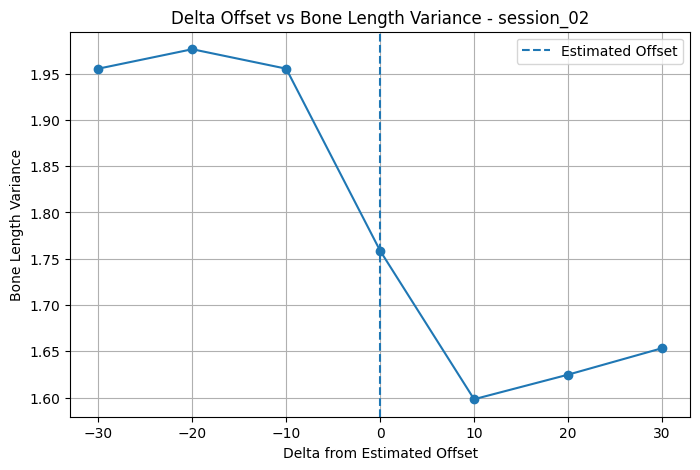

In [6]:
deltas = [
    row["delta"]
    for row in delta_results
]

bone_vars = [
    row["bone_length_variance"]
    for row in delta_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    deltas,
    bone_vars,
    marker="o"
)

plt.axvline(
    0,
    linestyle="--",
    label="Estimated Offset"
)

plt.title(
    f"Delta Offset vs Bone Length Variance - {session}"
)

plt.xlabel("Delta from Estimated Offset")
plt.ylabel("Bone Length Variance")

plt.legend()
plt.grid(True)

plt.show()

## Observation

The bone length variance changes when artificial temporal offsets are applied.

This indicates that temporal synchronization affects the stability of reconstructed 3D poses.

However, the relationship is not strictly monotonic because the current reconstruction uses simplified camera matrices instead of calibrated camera parameters.

## 7. Delta Offset vs Temporal Smoothness Error

Temporal Smoothness Error evaluates the consistency of motion over time.

A lower value indicates smoother reconstructed 3D motion.

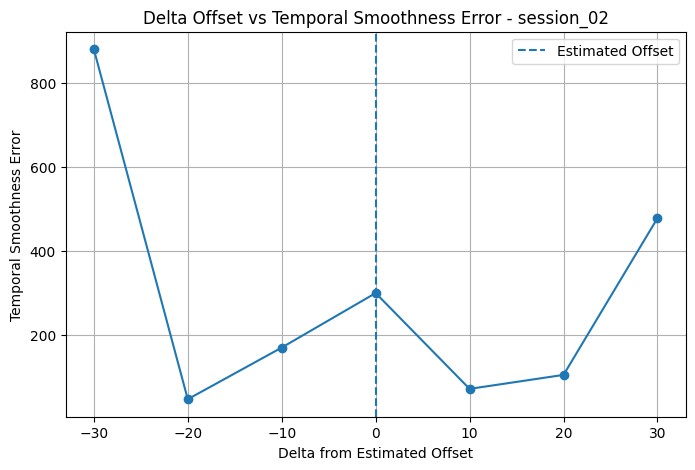

In [7]:
smoothness_values = [
    row["temporal_smoothness_error"]
    for row in delta_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    deltas,
    smoothness_values,
    marker="o"
)

plt.axvline(
    0,
    linestyle="--",
    label="Estimated Offset"
)

plt.title(
    f"Delta Offset vs Temporal Smoothness Error - {session}"
)

plt.xlabel("Delta from Estimated Offset")
plt.ylabel("Temporal Smoothness Error")

plt.legend()
plt.grid(True)

plt.show()

## 8. Discussion

The experiment shows that 3D reconstruction quality is sensitive to temporal alignment between camera views.

When the temporal offset changes, both bone length variance and temporal smoothness error also change.

This supports the importance of time synchronization in multi-view motion capture systems.

Since this project currently uses approximate camera matrices, the reconstructed 3D pose is not intended to be a precise metric-scale reconstruction. Instead, it is used to analyze how synchronization affects pose stability.